# 2D OSIRIS Photon Kinetics Tests and General Analysis Notebook

This notebook contains various tests and random functions I used throughout the course of testing the 2D photon kinetic code I implemented into OSIRIS. It uses my own Python analysis code I've called simutils, which will probably implement a lot of this functionality in the future to make my analysis as easy and streamlined as possible.

## Needed Imports

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from simutils.readers import osiris_load_density, osiris_load_efield

In [2]:
# Autoreload the simutils package whenever you make a change to the source code
%load_ext autoreload
%autoreload 2

## Plot a Snapshot of the Photon Density

This is just a simple plot of the photon distribution to ensure I'm doing everything correctly and actually getting a result.

In [3]:
dump=60
data, axes = osiris_load_density(dump=dump, species="photons", path="./")

weight = np.clip(data.sum(axis=0), 0, None)
centroid_x1 = np.sum(axes["x1"] * weight) / weight.sum()

track_width = 50.0
xlim_lo = max(centroid_x1 - track_width/2, axes["x1"][0])
xlim_hi = min(centroid_x1 + track_width/2, axes["x1"][-1])

plt.figure(figsize=(6, 5))
plt.imshow(data, origin="lower", aspect="auto",
           extent=[axes["x1"][0], axes["x1"][-1], axes["x2"][0], axes["x2"][-1]])
plt.xlim(xlim_lo, xlim_hi)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title(f"Photon Density; dump {dump}")
plt.colorbar()
plt.show()

FileNotFoundError: OSIRIS output file not found: MS/DENSITY/photons/charge/charge-photons-000060.h5

## Test 1: Thin Lens

The purpose of this test is to test the photon pusher alone. As there is only a small block of plasma that acts as a lens (which should, in turn, satisfy the thin lens approximation), 

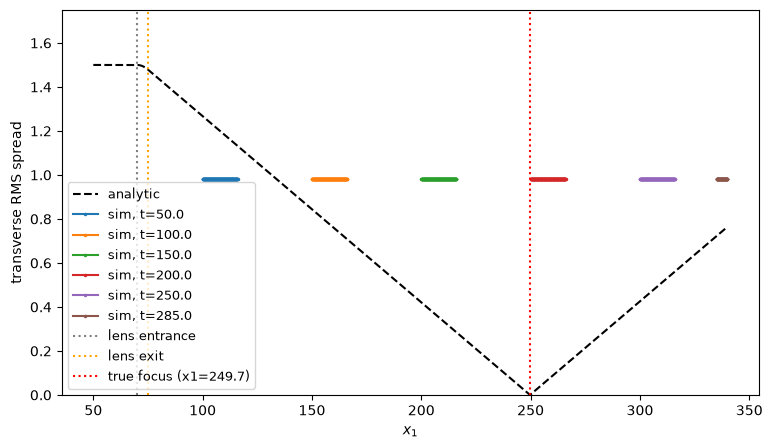

In [4]:
def photon_x2_rms_vs_x1(dump, run_dir=".", n_bins=200, min_particles=500):
    path = f"{run_dir}/MS/RAW/photons/RAW-photons-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        x1 = f["x1"][:]; x2 = f["x2"][:]; q = np.abs(f["q"][:])
        t = float(f.attrs["TIME"][0])
    bins = np.linspace(x1.min(), x1.max(), n_bins)
    idx = np.digitize(x1, bins)
    x1_centers, rms = [], []
    for b in range(1, n_bins):
        mask = idx == b
        if mask.sum() < min_particles:
            continue
        w = q[mask]
        mean_x2 = np.average(x2[mask], weights=w)
        var_x2 = np.average((x2[mask]-mean_x2)**2, weights=w)
        x1_centers.append(0.5*(bins[b-1]+bins[b]))
        rms.append(np.sqrt(var_x2))
    return np.array(x1_centers), np.array(rms), t

# analytic prediction -- UPDATED for the thicker (L=10) thin-lens deck
w_ch, beta, k0 = 3.0, 0.5, 6.928          # beta: 0.441 -> 0.2205
omega0 = np.sqrt(1 + k0**2)
Omega = np.sqrt(beta/(omega0**2 * w_ch**2))
z_lens0, z_lens1 = 70.0, 75.0                # z_lens1: 75.0 -> 80.0 (L=10, not 5)
x2_0 = 1.5

x1_analytic = np.linspace(50, 340, 800)       # range: 50-290 -> 50-340

rms_analytic = np.empty_like(x1_analytic)
for i, x1v in enumerate(x1_analytic):
    if x1v < z_lens0:
        rms_analytic[i] = x2_0
    elif x1v <= z_lens1:
        z = x1v - z_lens0
        rms_analytic[i] = x2_0*abs(np.cos(Omega*z))
    else:
        z_exit = z_lens1 - z_lens0
        slope = -Omega*np.sin(Omega*z_exit)
        rms_analytic[i] = x2_0*abs(np.cos(Omega*z_exit) + slope*(x1v - z_lens1))

# true focus location, computed from the exact model (not lens_exit + f=200,
# since that's only the approximate design target)
z_exit = z_lens1 - z_lens0
cos_exit = np.cos(Omega*z_exit)
slope_exit = -Omega*np.sin(Omega*z_exit)
true_focus = z_lens1 - cos_exit/slope_exit

plt.figure(figsize=(9,5))
plt.plot(x1_analytic, rms_analytic, 'k--', label='analytic')
for dump in [20, 40, 60, 80, 100, 114]:   # spread across the run; adjust once you know total dump count
    try:
        x1c, rms, t = photon_x2_rms_vs_x1(dump, ".")
    except FileNotFoundError:
        continue
    plt.plot(x1c, rms, marker='.', ms=3, label=f"sim, t={t:.1f}")
plt.axvline(z_lens0, color='gray', ls=':', label='lens entrance')
plt.axvline(z_lens1, color='orange', ls=':', label='lens exit')
plt.axvline(true_focus, color='red', ls=':', label=f'true focus (x1={true_focus:.1f})')
plt.ylim(0, 1.75)
plt.xlabel(r"$x_1$")
plt.ylabel(r"transverse RMS spread")
plt.legend(fontsize=9)
plt.show()

In [5]:
from matplotlib.colors import LinearSegmentedColormap


def load_density_2d(dump, species, run_dir=".", window_speed=None):
    """Load a 2D density field, returning (data_x1x2, x1_coords, x2_coords, time)."""
    path = f"{run_dir}/MS/DENSITY/{species}/charge/charge-{species}-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        data = f["charge"][:]              # (nx2, nx1) native storage order
        x1_min, x1_max = f["AXIS"]["AXIS1"][:]
        x2_min, x2_max = f["AXIS"]["AXIS2"][:]
        time = float(f.attrs["TIME"][0])
    data = data.T                           # -> (nx1, nx2)
    n0, n1 = data.shape

    if window_speed is not None:
        shift = window_speed * time
        x1_min -= shift
        x1_max -= shift

    x1_coords = np.linspace(x1_min, x1_max, n0)
    x2_coords = np.linspace(x2_min, x2_max, n1)
    return data, x1_coords, x2_coords, time

_BEAM_CMAP = LinearSegmentedColormap.from_list("beam", ["black", "darkred", "orange"])


def plot_wake_and_photon(dump, run_dir=".", plasma_species="plasma", photon_species="photons",
                          window_speed=1.0, plasma_cmap="Blues", plasma_vmax=None,
                          photon_vmax=None, alpha_gamma=1.0, figsize=(11, 5),
                          save_path=None, show=True):

    n_e, x1_e, x2_e, t_e = load_density_2d(dump, plasma_species, run_dir, window_speed)
    n_ph, x1_ph, x2_ph, t_ph = load_density_2d(dump, photon_species, run_dir, window_speed)

    # OSIRIS reports electron charge density as negative (q_electron < 0);
    # take the magnitude, matching the np.abs(osirisLoadDensity(...))
    # convention already used elsewhere for the plasma species.
    n_e = np.abs(n_e)

    fig, ax = plt.subplots(figsize=figsize)

    # --- plasma density: opaque base layer ---
    vmax_e = plasma_vmax if plasma_vmax is not None else n_e.max()
    im_e = ax.imshow(n_e.T, origin="lower", aspect="auto",
                      extent=[x1_e[0], x1_e[-1], x2_e[0], x2_e[-1]],
                      cmap=plasma_cmap, vmin=0, vmax=vmax_e)
    cbar_e = fig.colorbar(im_e, ax=ax, pad=0.02, fraction=0.046)
    cbar_e.set_label(f"{plasma_species} density")

    # --- photon/beam density: composited on top, alpha scales with density ---
    vmax_ph = photon_vmax if photon_vmax is not None else n_ph.max()
    if vmax_ph > 0:
        norm_ph = np.clip(n_ph / vmax_ph, 0, 1)
        rgba = _BEAM_CMAP(norm_ph)
        rgba[..., -1] = norm_ph ** alpha_gamma  # alpha channel from (normalized) density

        # imshow wants (row=y, col=x); data is (x1, x2) so transpose axes
        # 0 and 1 but keep the trailing RGBA axis as-is.
        rgba_img = np.transpose(rgba, (1, 0, 2))
        ax.imshow(rgba_img, origin="lower", aspect="auto",
                  extent=[x1_ph[0], x1_ph[-1], x2_ph[0], x2_ph[-1]])

        # separate colorbar for the beam overlay, positioned above/beside
        sm = plt.cm.ScalarMappable(cmap=_BEAM_CMAP, norm=plt.Normalize(0, vmax_ph))
        cbar_ph = fig.colorbar(sm, ax=ax, pad=0.08, fraction=0.046)
        cbar_ph.set_label(f"{photon_species} density")

    xlabel = r"$\xi = x_1 - v_{win}t$" if window_speed is not None else r"$x_1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$x_2$")
    ax.set_title(f"dump={dump}, t={t_e:.1f}")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=120)
    if show:
        plt.show()
    else:
        plt.close(fig)

    return n_e, n_ph

def save_frame_sequence(dumps, run_dir=".", plasma_species="plasma", photon_species="photons",
                         frames_dir="frames", window_speed=1.0, plasma_cmap="Blues",
                         alpha_gamma=1.0, figsize=(11, 5), global_clim=True):
    os.makedirs(frames_dir, exist_ok=True)

    plasma_vmax = photon_vmax = None
    if global_clim:
        pmax, phmax = 0.0, 0.0
        for dump in dumps:
            n_e, *_ = load_density_2d(dump, plasma_species, run_dir, window_speed)
            n_ph, *_ = load_density_2d(dump, photon_species, run_dir, window_speed)
            pmax = max(pmax, np.abs(n_e).max())
            phmax = max(phmax, n_ph.max())
        plasma_vmax, photon_vmax = pmax, phmax
        print(f"global clim: plasma vmax={plasma_vmax:.4g}, photon vmax={photon_vmax:.4g}")

    for i, dump in enumerate(dumps):
        out_path = os.path.join(frames_dir, f"{i:05d}.png")
        plot_wake_and_photon(
            dump, run_dir=run_dir, plasma_species=plasma_species, photon_species=photon_species,
            window_speed=window_speed, plasma_cmap=plasma_cmap,
            plasma_vmax=plasma_vmax, photon_vmax=photon_vmax,
            figsize=figsize,
            save_path=out_path, show=False,
        )
        if (i + 1) % 10 == 0 or i == len(dumps) - 1:
            print(f"saved {i+1}/{len(dumps)}")

    print(f"Frames saved to {frames_dir}/")


def find_available_dumps(run_dir, species):
    pattern = os.path.join(run_dir, "MS", "DENSITY", species, "charge", f"charge-{species}-*.h5")
    paths = sorted(glob.glob(pattern))
    dumps = [int(re.findall(r"-(\d+)\.h5$", os.path.basename(p))[0]) for p in paths]
    return dumps

In [6]:
dumps = find_available_dumps(".", "photons")
save_frame_sequence(dumps, run_dir=".", window_speed=1.0, frames_dir="wake_photon_frames")

NameError: name 'os' is not defined

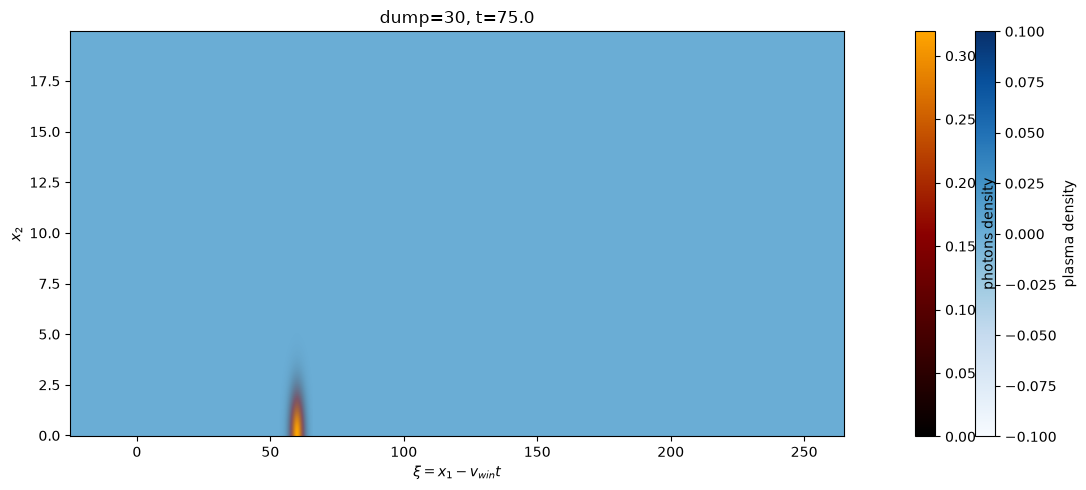

In [7]:
plot_wake_and_photon(dump=30, plasma_species="plasma", photon_species="photons");

In [20]:
from matplotlib.colors import LogNorm

def plot_wake_and_photon(dump, run_dir=".", plasma_species="plasma", photon_species="photons",
                          window_speed=1.0, plasma_cmap="Blues", plasma_vmax=None,
                          photon_vmax=None, photon_floor_frac=1e-3, alpha_high=0.95,
                          figsize=(11, 5), save_path=None, show=True):
    """
    photon_floor_frac: fraction of photon_vmax below which density is
        treated as "nothing here" -- fully transparent. Above this floor,
        color is mapped on a LOG scale between floor and vmax, so both the
        diffuse low-density cloud and the tightly focused peak get real,
        distinguishable color instead of the low end collapsing to a faint
        grey blend.
    alpha_high: opacity applied above the floor (constant, not a fade) --
        gives clean solid color rather than a washed-out blend with the
        plasma background.
    """
    n_e, x1_e, x2_e, t_e = load_density_2d(dump, plasma_species, run_dir, window_speed)
    n_ph, x1_ph, x2_ph, t_ph = load_density_2d(dump, photon_species, run_dir, window_speed)

    n_e = np.abs(n_e)

    fig, ax = plt.subplots(figsize=figsize)

    vmax_e = plasma_vmax if plasma_vmax is not None else n_e.max()
    im_e = ax.imshow(n_e.T, origin="lower", aspect="auto",
                      extent=[x1_e[0], x1_e[-1], x2_e[0], x2_e[-1]],
                      cmap=plasma_cmap, vmin=0, vmax=vmax_e)
    cbar_e = fig.colorbar(im_e, ax=ax, pad=0.02, fraction=0.046)
    cbar_e.set_label(f"{plasma_species} density")

    vmax_ph = photon_vmax if photon_vmax is not None else n_ph.max()
    if vmax_ph > 0:
        floor = vmax_ph * photon_floor_frac
        lognorm = LogNorm(vmin=floor, vmax=vmax_ph, clip=True)

        # anything at/below the floor -> fully transparent; above it -> log-mapped color, constant alpha
        above_floor = n_ph > floor
        color_val = np.zeros_like(n_ph)
        color_val[above_floor] = lognorm(n_ph[above_floor])

        rgba = _BEAM_CMAP(color_val)
        rgba[..., -1] = np.where(above_floor, alpha_high, 0.0)

        rgba_img = np.transpose(rgba, (1, 0, 2))
        ax.imshow(rgba_img, origin="lower", aspect="auto",
                  extent=[x1_ph[0], x1_ph[-1], x2_ph[0], x2_ph[-1]])

        sm = plt.cm.ScalarMappable(cmap=_BEAM_CMAP, norm=lognorm)
        cbar_ph = fig.colorbar(sm, ax=ax, pad=0.08, fraction=0.046)
        cbar_ph.set_label(f"{photon_species} density (log)")

    xlabel = r"$\xi = x_1 - v_{win}t$" if window_speed is not None else r"$x_1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$x_2$")
    ax.set_title(f"dump={dump}, t={t_e:.1f}")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=120)
    if show:
        plt.show()
    else:
        plt.close(fig)

    return n_e, n_ph

In [21]:
def _rhs_single(x1, y, p1, w_ch, beta, z_lens0, z_lens1, channel_bottom):
    x2, p2 = y
    dx2dx1 = p2 / p1
    if z_lens0 <= x1 <= z_lens1:
        dndx2 = 2.0 * beta * x2 / w_ch**2
    else:
        dndx2 = 0.0
    dp2dx1 = -0.5 * dndx2 / p1
    return [dx2dx1, dp2dx1]


def _p1_after_jump(p1_before, p2, n_before, n_after):
    """
    Crossing a sharp x1-interface where n jumps: omega and p2 (tangent to
    the interface) stay continuous, p1 (normal to the interface) adjusts.
    """
    val = p1_before**2 + n_before - n_after
    return np.sqrt(max(val, 0.0))


def predict_refraction_trajectory(target_tag, dumps, run_dir=".",
                                   w_ch=3.0, beta=0.5, z_lens0=70.0, z_lens1=75.0,
                                   channel_bottom=1.0, n_dense=2000):
    """
    Same computation as track_and_compare_with_refraction, but returns the
    data without plotting -- used both standalone and by
    plot_multi_particle_comparison for overlaying several particles.
    """
    traj = build_trajectory(target_tag, dumps, run_dir)
    order = np.argsort(traj["x1"])
    x1_meas = traj["x1"][order]
    x2_meas = traj["x2"][order]
    p1_meas = traj["p1"][order]
    p2_meas = traj["p2"][order]

    p1_0, x2_0, p2_0 = p1_meas[0], x2_meas[0], p2_meas[0]
    x1_start = x1_meas[0]

    x2_entrance = x2_0 + (p2_0 / p1_0) * (z_lens0 - x1_start)
    p2_entrance = p2_0

    n_out = channel_bottom
    n_in = channel_bottom + beta * (x2_entrance / w_ch) ** 2
    p1_channel = _p1_after_jump(p1_0, p2_entrance, n_out, n_in)

    sol2 = solve_ivp(_rhs_single, (z_lens0, z_lens1), [x2_entrance, p2_entrance],
                      args=(p1_channel, w_ch, beta, z_lens0, z_lens1, channel_bottom),
                      max_step=0.01, rtol=1e-10, atol=1e-12, dense_output=True)
    x2_exit, p2_exit = sol2.y[0, -1], sol2.y[1, -1]

    n_in2 = channel_bottom + beta * (x2_exit / w_ch) ** 2
    n_out2 = channel_bottom
    p1_after = _p1_after_jump(p1_channel, p2_exit, n_in2, n_out2)

    def predict(x1_query):
        x1_query = np.atleast_1d(x1_query)
        out = np.empty_like(x1_query, dtype=float)
        m1 = x1_query < z_lens0
        m2 = (x1_query >= z_lens0) & (x1_query <= z_lens1)
        m3 = x1_query > z_lens1
        out[m1] = x2_0 + (p2_0 / p1_0) * (x1_query[m1] - x1_start)
        if m2.any():
            out[m2] = sol2.sol(x1_query[m2])[0]
        out[m3] = x2_exit + (p2_exit / p1_after) * (x1_query[m3] - z_lens1)
        return out

    x1_dense = np.linspace(x1_start, x1_meas[-1], n_dense)
    x2_dense_pred = predict(x1_dense)
    residual = x2_meas - predict(x1_meas)

    return dict(x1_meas=x1_meas, x2_meas=x2_meas, x1_dense=x1_dense,
                x2_dense_pred=x2_dense_pred, residual=residual,
                p1_entrance=p1_0, p1_channel=p1_channel, p1_exit=p1_after)


def plot_multi_particle_comparison(tags, dumps, run_dir=".",
                                    w_ch=3.0, beta=0.5, z_lens0=70.0, z_lens1=75.0,
                                    channel_bottom=1.0, labels=None):
    """
    Overlay several tracked particles' measured trajectories against their
    own refraction-corrected prediction curves, styled like the ensemble
    RMS-vs-x1 plot: one color per particle, dashed prediction curve behind
    the sim points, lens boundaries marked. Good for visually showing how
    the match degrades with entrance amplitude.

        tags: list of (node, local_id) tuples
        labels: optional list of strings for the legend, e.g. ["x2~1","x2~7.5"]
    """
    fig, ax = plt.subplots(figsize=(9, 5.5))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, tag in enumerate(tags):
        r = predict_refraction_trajectory(tag, dumps, run_dir,
                                           w_ch, beta, z_lens0, z_lens1, channel_bottom)
        c = colors[i % len(colors)]
        label = labels[i] if labels is not None else f"tag={tag}"
        ax.plot(r["x1_dense"], r["x2_dense_pred"], '--', color=c, lw=1, alpha=0.7)
        ax.plot(r["x1_meas"], r["x2_meas"], '.', ms=4, color=c, label=label)

    ax.axvline(z_lens0, color='gray', ls=':', label='lens entrance')
    ax.axvline(z_lens1, color='orange', ls=':', label='lens exit')
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def track_and_compare_with_refraction(target_tag, dumps, run_dir=".",
                                       w_ch=3.0, beta=0.5, z_lens0=70.0, z_lens1=75.0,
                                       channel_bottom=1.0, n_dense=2000):
    """
    Same as track_and_compare, but treats z_lens0/z_lens1 as sharp
    interfaces where p1 jumps (Snell's-law-like refraction) instead of
    assuming p1 is constant across the whole domain. Only the SEGMENT
    between the two boundaries uses a different (locally constant) p1 than
    the segments before/after -- p1 is still exactly conserved WITHIN each
    of the three segments, just not across the two crossings.
    """
    traj = build_trajectory(target_tag, dumps, run_dir)
    order = np.argsort(traj["x1"])
    x1_meas = traj["x1"][order]
    x2_meas = traj["x2"][order]
    p1_meas = traj["p1"][order]
    p2_meas = traj["p2"][order]

    p1_0, x2_0, p2_0 = p1_meas[0], x2_meas[0], p2_meas[0]
    x1_start = x1_meas[0]

    # --- segment 1: ballistic up to z_lens0 ---
    x2_entrance = x2_0 + (p2_0 / p1_0) * (z_lens0 - x1_start)
    p2_entrance = p2_0

    # --- boundary jump IN ---
    n_out = channel_bottom
    n_in = channel_bottom + beta * (x2_entrance / w_ch) ** 2
    p1_channel = _p1_after_jump(p1_0, p2_entrance, n_out, n_in)

    # --- segment 2: through the channel with p1_channel ---
    sol2 = solve_ivp(_rhs_single, (z_lens0, z_lens1), [x2_entrance, p2_entrance],
                      args=(p1_channel, w_ch, beta, z_lens0, z_lens1, channel_bottom),
                      max_step=0.01, rtol=1e-10, atol=1e-12, dense_output=True)
    x2_exit, p2_exit = sol2.y[0, -1], sol2.y[1, -1]

    # --- boundary jump OUT ---
    n_in2 = channel_bottom + beta * (x2_exit / w_ch) ** 2
    n_out2 = channel_bottom
    p1_after = _p1_after_jump(p1_channel, p2_exit, n_in2, n_out2)

    # --- evaluate the full piecewise prediction on a dense grid and at measured points ---
    def predict(x1_query):
        x1_query = np.atleast_1d(x1_query)
        out = np.empty_like(x1_query, dtype=float)
        m1 = x1_query < z_lens0
        m2 = (x1_query >= z_lens0) & (x1_query <= z_lens1)
        m3 = x1_query > z_lens1
        out[m1] = x2_0 + (p2_0 / p1_0) * (x1_query[m1] - x1_start)
        if m2.any():
            out[m2] = sol2.sol(x1_query[m2])[0]
        out[m3] = x2_exit + (p2_exit / p1_after) * (x1_query[m3] - z_lens1)
        return out

    x1_dense = np.linspace(x1_start, x1_meas[-1], n_dense)
    x2_dense_pred = predict(x1_dense)
    x2_meas_pred = predict(x1_meas)
    residual = x2_meas - x2_meas_pred

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(x1_dense, x2_dense_pred, 'k-', lw=1, label="exact ODE + boundary refraction")
    ax1.plot(x1_meas, x2_meas, 'o', ms=4, color='C0', label="sim (measured)")
    ax1.axvline(z_lens0, color='gray', ls=':')
    ax1.axvline(z_lens1, color='orange', ls=':')
    ax1.set_ylabel(r"$x_2$")
    ax1.set_title(f"p1: entrance={p1_0:.4f}  in-channel={p1_channel:.4f}  exit={p1_after:.4f}")
    ax1.legend(fontsize=9)

    ax2.plot(x1_meas, residual, 'o-', ms=4, color='C3')
    ax2.axhline(0, color='k', ls='--', lw=1)
    ax2.axvline(z_lens0, color='gray', ls=':')
    ax2.axvline(z_lens1, color='orange', ls=':')
    ax2.set_xlabel(r"$x_1$")
    ax2.set_ylabel("residual\n(measured - refraction-corrected ODE)")
    plt.tight_layout()
    plt.show()

    print(f"p1 entrance={p1_0:.5f}  p1 in-channel={p1_channel:.5f}  p1 exit={p1_after:.5f}")
    print(f"residual: mean={np.mean(residual):+.6f}  std={np.std(residual):.6f}  "
          f"max|.|={np.max(np.abs(residual)):.6f}")
    print()
    print("Compare max|residual| to the previous (no-refraction) run's 0.57 --")
    print("if this collapses it, the boundary refraction was the missing piece.")

    return dict(x1_meas=x1_meas, x2_meas=x2_meas, residual=residual,
                p1_entrance=p1_0, p1_channel=p1_channel, p1_exit=p1_after)


def predict_thin_lens_exact(x2_entrance, p1_entrance, p2_entrance,
                             x1_query, w_ch, beta, z_lens0, z_lens1,
                             channel_bottom=1.0):
    """
    Rigorous thin-lens model: the ONLY approximation is that x2 doesn't
    move while crossing the lens (valid for L << f). Everything else is
    exact -- the entrance/exit boundary jumps use the same omega-conserving
    refraction physics as the full thick-lens model (predict_refraction_
    trajectory), and the interior kick uses the exact force law, not any
    small-angle/paraxial substitution. No Omega, no omega0, no linearization.

    Because x2 is frozen, the entrance and exit boundary jumps are exact
    inverses of each other -- p1 returns to p1_entrance after the lens,
    which falls out of the algebra rather than being assumed.
    """
    L = z_lens1 - z_lens0

    # entrance jump (exact, omega-conservation)
    n_out = channel_bottom
    n_in = channel_bottom + beta * (x2_entrance / w_ch) ** 2
    p1_channel = _p1_after_jump(p1_entrance, p2_entrance, n_out, n_in)

    # interior kick: x2 frozen -> dn/dx2 constant -> exact trivial integral
    dndx2_frozen = 2.0 * beta * x2_entrance / w_ch**2
    delta_p2 = -0.5 * dndx2_frozen / p1_channel * L
    p2_after = p2_entrance + delta_p2

    # exit jump: algebraically exact inverse of the entrance jump (verify)
    p1_after = _p1_after_jump(p1_channel, p2_after, n_in, n_out)
    # p1_after should equal p1_entrance to numerical precision -- returned
    # for you to check this directly if you want the sanity check visible

    z_mid = 0.5 * (z_lens0 + z_lens1)
    x1_query = np.atleast_1d(x1_query)
    out = np.empty_like(x1_query, dtype=float)
    before = x1_query < z_mid
    after = ~before
    out[before] = x2_entrance + (p2_entrance / p1_entrance) * (x1_query[before] - z_lens0)
    out[after] = x2_entrance + (p2_after / p1_after) * (x1_query[after] - z_mid)

    return out, p1_after, p2_after


def thin_lens_focal_length(w_ch, beta, k0):
    """Paraxial thin-lens focal length for this GRIN channel: f = 1/(Omega^2 * L)."""
    omega0 = np.sqrt(1 + k0**2)
    Omega = np.sqrt(beta / (omega0**2 * w_ch**2))
    return Omega, omega0


def predict_thin_lens(x2_entrance, slope_entrance, x1_query, w_ch, beta, k0,
                       z_lens0, z_lens1):
    """
    Classic textbook thin-lens approximation: x2 unchanged across the lens,
    slope kicked by -x2/f at a single plane (lens midpoint). Valid only
    when L << f -- check that assumption before trusting this over the
    full thick-lens (predict_refraction_trajectory) result.

    NOTE: this ALSO carries a small-angle assumption baked into Omega/f
    (uses the nominal omega0 rather than this particle's own p1). Use
    predict_thin_lens_exact instead if you want the thin-lens approximation
    with no small-angle assumption riding along with it.
    """
    Omega, omega0 = thin_lens_focal_length(w_ch, beta, k0)
    L = z_lens1 - z_lens0
    f = 1.0 / (Omega**2 * L)
    z_mid = 0.5 * (z_lens0 + z_lens1)

    x1_query = np.atleast_1d(x1_query)
    out = np.empty_like(x1_query, dtype=float)

    before = x1_query < z_mid
    after = ~before
    out[before] = x2_entrance + slope_entrance * (x1_query[before] - z_lens0)

    x2_at_mid = x2_entrance + slope_entrance * (z_mid - z_lens0)
    slope_after = slope_entrance - x2_at_mid / f
    out[after] = x2_at_mid + slope_after * (x1_query[after] - z_mid)

    return out, f


def track_and_compare(target_tag, dumps, run_dir=".",
                       w_ch=3.0, beta=0.5, z_lens0=70.0, z_lens1=75.0,
                       channel_bottom=1.0, n_dense=2000):
    """
    target_tag: a (node, local_id) tuple, e.g. from list_tags_in_dump()
                in track_single_photon.py.
    dumps: iterable of dump indices to search for this tag (needs to span
           from before the channel to as far downstream as you want to test).
    """
    traj = build_trajectory(target_tag, dumps, run_dir)
    if len(traj["x1"]) < 2:
        raise RuntimeError(
            f"Only found {len(traj['x1'])} matches for tag {target_tag} -- "
            f"need at least 2 to seed and check the integration. Try a "
            f"wider/denser `dumps` range."
        )

    order = np.argsort(traj["x1"])
    x1_meas = traj["x1"][order]
    x2_meas = traj["x2"][order]
    p1_meas = traj["p1"][order]
    p2_meas = traj["p2"][order]

    # seed from the earliest available measurement -- p1 is this particle's
    # own conserved value, so any chromatic effect from uth(1) is exact here,
    # not approximated
    p1 = p1_meas[0]
    x2_0, p2_0 = x2_meas[0], p2_meas[0]

    x1_dense = np.linspace(x1_meas[0], x1_meas[-1], n_dense)
    sol = solve_ivp(_rhs_single, (x1_meas[0], x1_meas[-1]), [x2_0, p2_0],
                     args=(p1, w_ch, beta, z_lens0, z_lens1, channel_bottom),
                     t_eval=x1_dense, max_step=0.05, rtol=1e-10, atol=1e-12)
    x2_dense_pred = sol.y[0]

    # also predict exactly AT the measured x1 points, for a clean residual
    sol_at_meas = solve_ivp(_rhs_single, (x1_meas[0], x1_meas[-1]), [x2_0, p2_0],
                             args=(p1, w_ch, beta, z_lens0, z_lens1, channel_bottom),
                             t_eval=x1_meas, max_step=0.05, rtol=1e-10, atol=1e-12)
    x2_meas_pred = sol_at_meas.y[0]
    residual = x2_meas - x2_meas_pred

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

    ax1.plot(x1_dense, x2_dense_pred, 'k-', lw=1, label="exact ODE (this particle's own p1)")
    ax1.plot(x1_meas, x2_meas, 'o', ms=4, color='C0', label="sim (measured)")
    ax1.axvline(z_lens0, color='gray', ls=':')
    ax1.axvline(z_lens1, color='orange', ls=':')
    ax1.set_ylabel(r"$x_2$")
    ax1.set_title(f"tag={target_tag}, p1={p1:.4f}")
    ax1.legend(fontsize=9)

    ax2.plot(x1_meas, residual, 'o-', ms=4, color='C3')
    ax2.axhline(0, color='k', ls='--', lw=1)
    ax2.axvline(z_lens0, color='gray', ls=':')
    ax2.axvline(z_lens1, color='orange', ls=':')
    ax2.set_xlabel(r"$x_1$")
    ax2.set_ylabel("residual\n(measured - exact ODE)")

    plt.tight_layout()
    plt.show()

    print(f"p1 (this particle) = {p1:.5f}")
    print(f"n points            = {len(x1_meas)}")
    print(f"residual: mean={np.mean(residual):+.6f}  std={np.std(residual):.6f}  "
          f"max|.|={np.max(np.abs(residual)):.6f}")
    print()
    print("If |residual| stays flat/small across the full x1 range -- including")
    print("far past the lens exit -- the per-particle physics/numerics are fine")
    print("and the RMS-plot gap is a binning/statistics artifact. If |residual|")
    print("visibly grows with distance past the exit, that's real compounding")
    print("drift (numerical dt-truncation is the next thing to check: halve dt")
    print("in the deck and see if it shrinks).")

    return dict(x1_meas=x1_meas, x2_meas=x2_meas, x2_meas_pred=x2_meas_pred,
                residual=residual, x1_dense=x1_dense, x2_dense_pred=x2_dense_pred, p1=p1)

In [22]:
"""
Ensemble RMS-vs-x1 curve using the exact (no small-angle) thin-lens model
-- same theory as predict_thin_lens_exact, but applied to a whole virtual
population at once and vectorized, since the thin-lens kick is pure
algebra (no ODE integration needed, unlike the thick-lens ensemble).

    x1_analytic = np.linspace(50, 340, 800)
    rms_thin = build_thin_lens_rms_curve(x1_analytic, sigma_x2=1.5,
                                          w_ch=3.0, beta=0.5, k0=6.928,
                                          z_lens0=70.0, z_lens1=75.0)
    plt.plot(x1_analytic, rms_thin, 'k--', label='analytic (thin lens, exact)')
"""

import numpy as np


def build_thin_lens_rms_curve(x1_grid, sigma_x2=1.5, w_ch=3.0, beta=0.5, k0=6.928,
                               z_lens0=70.0, z_lens1=75.0, channel_bottom=1.0,
                               n_virtual=20000, seed=0):
    """
    Samples a virtual ensemble matching your launch distribution
    (x2 ~ N(0, sigma_x2), zero angular spread, matching uth(2)=0), applies
    the exact thin-lens kick to each (vectorized -- no per-particle solve_ivp),
    and returns the RMS at each x1_grid point.
    """
    x1_grid = np.asarray(x1_grid)
    L = z_lens1 - z_lens0
    z_mid = 0.5 * (z_lens0 + z_lens1)

    rng = np.random.default_rng(seed)
    x2_entrance = rng.normal(0.0, sigma_x2, n_virtual)
    p1_entrance = np.full(n_virtual, k0)
    p2_entrance = np.zeros(n_virtual)   # zero angular spread, matches uth(2)=0

    # --- entrance jump (vectorized) ---
    n_out = channel_bottom
    n_in = channel_bottom + beta * (x2_entrance / w_ch) ** 2
    val = p1_entrance**2 + n_out - n_in
    p1_channel = np.sqrt(np.clip(val, 0.0, None))

    # --- interior kick: x2 frozen -> trivial integral ---
    dndx2_frozen = 2.0 * beta * x2_entrance / w_ch**2
    delta_p2 = -0.5 * dndx2_frozen / p1_channel * L
    p2_after = p2_entrance + delta_p2

    # --- exit jump (should return p1 to p1_entrance, vectorized) ---
    val2 = p1_channel**2 + n_in - n_out
    p1_after = np.sqrt(np.clip(val2, 0.0, None))

    # --- evaluate x2(x1) for the whole ensemble at once ---
    x2_traj = np.empty((n_virtual, len(x1_grid)))
    before = x1_grid < z_mid
    after = ~before

    # before the kick plane: flat (p2_entrance=0) straight line from entrance
    x2_traj[:, before] = (x2_entrance[:, None]
                           + np.outer(p2_entrance / p1_entrance, x1_grid[before] - z_lens0))
    # after the kick plane: new slope
    x2_traj[:, after] = (x2_entrance[:, None]
                          + np.outer(p2_after / p1_after, x1_grid[after] - z_mid))

    rms = np.sqrt(np.mean(x2_traj**2, axis=0))
    return rms


def find_focus(x1_grid, rms_curve):
    i_min = np.argmin(rms_curve)
    return x1_grid[i_min], rms_curve[i_min]

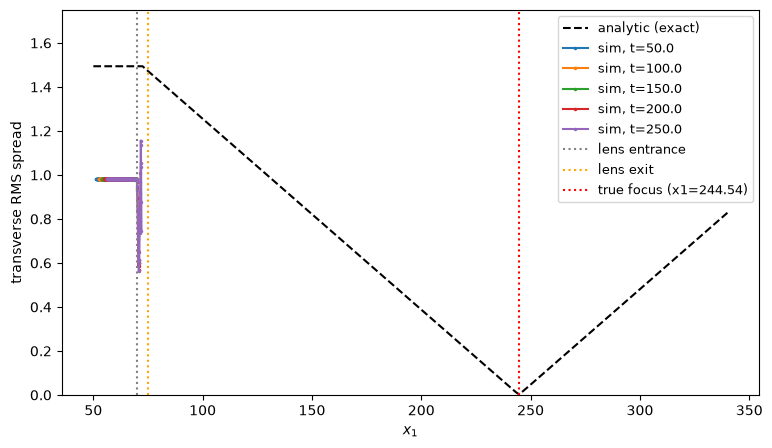

In [23]:
x1_analytic = np.linspace(50, 340, 800)
rms_analytic = build_thin_lens_rms_curve(
    x1_analytic, sigma_x2=1.5, w_ch=3.0, beta=0.5, k0=6.928,
    z_lens0=70.0, z_lens1=75.0)

true_focus, focus_rms = find_focus(x1_analytic, rms_analytic)

# --- the rest of your plotting code is unchanged ---
plt.figure(figsize=(9, 5))
plt.plot(x1_analytic, rms_analytic, 'k--', label='analytic (exact)')
for dump in [20, 40, 60, 80, 100]:
    try:
        x1c, rms, t = photon_x2_rms_vs_x1(dump, ".")
    except FileNotFoundError:
        continue
    plt.plot(x1c, rms, marker='.', ms=3, label=f"sim, t={t:.1f}")
plt.axvline(z_lens0, color='gray', ls=':', label='lens entrance')
plt.axvline(z_lens1, color='orange', ls=':', label='lens exit')
plt.axvline(true_focus, color='red', ls=':', label=f'true focus (x1={true_focus:.2f})')
plt.ylim(0, 1.75)
plt.xlabel(r"$x_1$")
plt.ylabel(r"transverse RMS spread")
plt.legend(fontsize=9)
plt.show()

In [24]:
def photon_x2_rms_vs_x1(dump, run_dir=".", n_bins=150, min_particles=3500,
                         sigma_clip=4.0, n_clip_iter=3):
    path = f"{run_dir}/MS/RAW/photons/RAW-photons-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        x1 = f["x1"][:]; x2 = f["x2"][:]; q = np.abs(f["q"][:])
        t = float(f.attrs["TIME"][0])

    bins = np.linspace(x1.min(), x1.max(), n_bins)
    idx = np.digitize(x1, bins)
    x1_centers, rms = [], []

    for b in range(1, n_bins):
        mask = idx == b
        if mask.sum() < min_particles:
            continue
        xb, wb = x2[mask], q[mask]

        # iterative weighted sigma-clipping: drop stray outliers, refit, repeat
        keep = np.ones(xb.shape, dtype=bool)
        for _ in range(n_clip_iter):
            wm = np.average(xb[keep], weights=wb[keep])
            wstd = np.sqrt(np.average((xb[keep] - wm) ** 2, weights=wb[keep]))
            new_keep = np.abs(xb - wm) < sigma_clip * wstd
            if new_keep.sum() < min_particles:
                break  # don't clip below the statistics floor
            keep = new_keep

        wm = np.average(xb[keep], weights=wb[keep])
        var = np.average((xb[keep] - wm) ** 2, weights=wb[keep])
        x1_centers.append(0.5 * (bins[b - 1] + bins[b]))
        rms.append(np.sqrt(var))

    return np.array(x1_centers), np.array(rms), t

## Test 2: Full Example

Now we move on to a test of the full cycle: photon pusher as well as the photon feedback correction. We'll compare this to a run of the full EM version.

In [25]:
import numpy as np
from scipy.signal import hilbert

def demodulated_envelope(E, dx1, k0, decimate=20):
    """E: real 1D field slice along x1. Returns the decimated complex
    envelope and its new effective sample spacing."""
    analytic = hilbert(E)                          # step 1: analytic signal
    x1 = np.arange(len(E)) * dx1
    baseband = analytic * np.exp(-1j * k0 * x1)     # step 2: demodulate
    envelope = baseband[::decimate]                 # step 3: decimate
    return envelope, dx1 * decimate

def wigner_ville_fast(z, dx, n_lag=None):
    """Fully vectorized WVD -- one FFT call, no Python-level loop over
    positions. z: complex signal (e.g. the demodulated envelope above)."""
    N = len(z)
    if n_lag is None:
        n_lag = min(N // 2, 256)
    M = n_lag
    zpad = np.concatenate([np.zeros(M, dtype=complex), z, np.zeros(M, dtype=complex)])
    idx = np.arange(N)[:, None] + M
    m = np.arange(-M, M + 1)[None, :]
    A = zpad[idx + m] * np.conj(zpad[idx - m])       # shape (N, 2M+1), built with no loop
    W = np.fft.fftshift(np.fft.fft(A, axis=1), axes=1).real
    k_axis = np.fft.fftshift(np.fft.fftfreq(2 * M + 1, d=dx)) * 2 * np.pi
    x_axis = np.arange(N) * dx
    return x_axis, k_axis, W

def load_field_slice(dump, field="e2", x2_target=0.0, run_dir="."):
    path = f"{run_dir}/MS/FLD/{field}/{field}-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        data = f[field][:]                # shape (nx2, nx1), same convention as density
        ax1 = f["AXIS/AXIS1"][:]
        ax2 = f["AXIS/AXIS2"][:]
        t = float(f.attrs["TIME"][0])
    x1 = np.linspace(ax1[0], ax1[1], data.shape[1])
    x2 = np.linspace(ax2[0], ax2[1], data.shape[0])
    j = np.argmin(np.abs(x2 - x2_target))
    return x1, data[j, :], t

In [26]:
x1, E2_slice, t = load_field_slice(dump=20, field="e2", x2_target=0.0)
dx1 = x1[1] - x1[0]

envelope, dx_eff = demodulated_envelope(E2_slice, dx1, k0=7.0, decimate=20)
x1_axis, dk_axis, W = wigner_ville_fast(envelope, dx_eff)
p1_axis = 7.0 + dk_axis

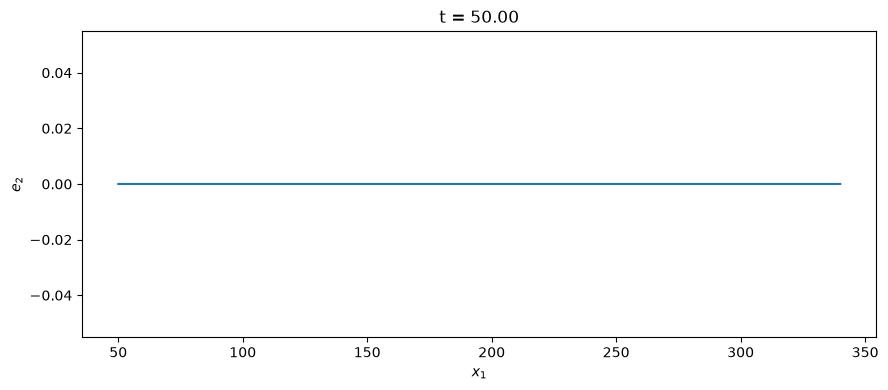

In [27]:
plt.figure(figsize=(9, 4))
plt.plot(x1, E2_slice)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$e_2$")
plt.title(f"t = {t:.2f}")
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from scipy.signal import savgol_filter
from tftb.processing import WignerVilleDistribution


def next_even(n):
    return n if n % 2 == 0 else n + 1


def load_field_2d(dump, field="e2", run_dir=".", ms_dir="MS_em"):
    path = f"{run_dir}/{ms_dir}/FLD/{field}/{field}-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        data = f[field][:]
        ax1 = f["AXIS/AXIS1"][:]
        ax2 = f["AXIS/AXIS2"][:]
        t = float(f.attrs["TIME"][0])
    x1 = np.linspace(ax1[0], ax1[1], data.shape[1])
    x2 = np.linspace(ax2[0], ax2[1], data.shape[0])
    return x1, x2, data, t


def load_density_2d(dump, species="plasma", run_dir=".", ms_dir="MS_em"):
    path = f"{run_dir}/{ms_dir}/DENSITY/{species}/charge/charge-{species}-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        dset = next(c for c in ("charge", species, "rho") if c in f)
        data = -f[dset][:]  # flip sign -- "charge" is negative for electrons
        ax1 = f["AXIS/AXIS1"][:]
        ax2 = f["AXIS/AXIS2"][:]
    x1 = np.linspace(ax1[0], ax1[1], data.shape[1])
    x2 = np.linspace(ax2[0], ax2[1], data.shape[0])
    return x1, x2, data


def find_matching_pkt_dump(target_t, run_dir=".", ms_dir="MS", max_dump=200, tol=None):
    best_dump, best_diff = None, np.inf
    for d in range(max_dump):
        try:
            with h5py.File(f"{run_dir}/{ms_dir}/RAW/photons/RAW-photons-{d:06d}.h5", "r") as f:
                t = float(f.attrs["TIME"][0])
        except FileNotFoundError:
            continue
        diff = abs(t - target_t)
        if diff < best_diff:
            best_dump, best_diff = d, diff
    if tol is not None and best_diff > tol:
        raise RuntimeError(f"closest PKT dump is {best_diff:.2f} off target time {target_t}")
    return best_dump, best_diff


def load_pkt_photons(dump, x2_target, x2_tol, run_dir=".", ms_dir="MS"):
    with h5py.File(f"{run_dir}/{ms_dir}/RAW/photons/RAW-photons-{dump:06d}.h5", "r") as f:
        x1, x2, p1, q = f["x1"][:], f["x2"][:], f["p1"][:], np.abs(f["q"][:])
        t = float(f.attrs["TIME"][0])
    mask = np.abs(x2 - x2_target) < x2_tol
    return x1[mask], p1[mask], q[mask], t


def wigner_lineout(x1, E_x, wig_cutoff=0.01, n_sigma_interference=3):
    dx1 = x1[1] - x1[0]
    E_pad = np.pad(E_x, (0, next_even(np.size(E_x)) - np.size(E_x)), 'constant')
    wig = WignerVilleDistribution(E_pad)
    W_E, xi_wig, f_wig = wig.run()

    xi_wig = dx1 * xi_wig + x1[0]
    nbin = int(np.size(f_wig) / 2)
    f_wig = f_wig[:nbin] / dx1
    W_E = W_E[:nbin, :]
    k_wig = 2 * np.pi * f_wig

    power = np.abs(E_x) ** 2
    xi_centroid = np.sum(x1 * power) / np.sum(power)
    sigma_xi = np.sqrt(np.sum(x1**2 * power) / np.sum(power) - xi_centroid**2)

    k_full = 2 * np.pi * np.fft.fftfreq(len(x1), d=dx1)
    E_k = np.fft.fft(E_x)
    pos_mask = k_full > 0
    k_pos = k_full[pos_mask]
    powspectrum = np.abs(E_k[pos_mask]) ** 2
    k_centroid = np.sum(k_pos * powspectrum) / np.sum(powspectrum)
    sigma_k = np.sqrt(np.sum((k_pos - k_centroid) ** 2 * powspectrum) / np.sum(powspectrum))

    Xi, K = np.meshgrid(xi_wig, k_wig)
    W_E[np.abs(W_E) < wig_cutoff * np.max(np.abs(W_E))] = 0
    W_E[np.abs(K - k_centroid) > n_sigma_interference * sigma_k] = 0
    W_E[Xi < (xi_centroid - 2 * sigma_xi)] = 0
    return xi_wig, k_wig, np.ma.masked_where(W_E == 0, W_E)


def compare_wigner_density(dump_em, x2_target=0.0, x2_tol=1.0,
                            field="e2", run_dir=".", ms_dir_em="MS_em", ms_dir_pkt="MS",
                            pkt_max_dump=200,
                            smooth_window_per_dxi_em=0.06, smooth_window_per_dxi_pkt=0.01,
                            k_laser=7.0, wig_cutoff=0.01, n_sigma_interference=3,
                            figsize=(14, 8)):

    x1_em, x2_em, field_2d, t_em = load_field_2d(dump_em, field, run_dir, ms_dir_em)
    j_em = np.argmin(np.abs(x2_em - x2_target))
    E_slice = field_2d[j_em, :]

    dump_pkt, t_diff = find_matching_pkt_dump(t_em, run_dir, ms_dir_pkt, pkt_max_dump)

    # --- density + smoothed gradient, EM ---
    x1_dens_em, x2_dens_em, dens_em_2d = load_density_2d(dump_em, "plasma", run_dir, ms_dir_em)
    j_dens_em = np.argmin(np.abs(x2_dens_em - x2_target))
    n_em = dens_em_2d[j_dens_em, :]
    w_em = next_even(int(smooth_window_per_dxi_em * np.size(x1_dens_em))) + 1
    gradn_em = smoothed_gradient(x1_dens_em, n_em, smooth_window_x1=0.3)

    # --- density + gradient, PKT ---
    x1_dens_pkt, x2_dens_pkt, dens_pkt_2d = load_density_2d(dump_pkt, "plasma", run_dir, ms_dir_pkt)
    j_dens_pkt = np.argmin(np.abs(x2_dens_pkt - x2_target))
    n_pkt = dens_pkt_2d[j_dens_pkt, :]
    dxi_pkt = x1_dens_pkt[1] - x1_dens_pkt[0]
    gradn_pkt = smoothed_gradient(x1_dens_pkt, n_pkt, smooth_window_x1=0.3)

    # --- Wigner transform of the EM field slice ---
    xi_wig, k_wig, W_E = wigner_lineout(x1_em, E_slice, wig_cutoff, n_sigma_interference)
    k_wig_norm = k_wig / k_laser

    # --- PKT photon phase space, same style as reference (turbo + sqrt alpha) ---
    x1_pkt, p1_pkt, q_pkt, t_pkt = load_pkt_photons(dump_pkt, x2_target, x2_tol, run_dir, ms_dir_pkt)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    if len(x1_pkt) > 0:
        h, xedges, yedges = np.histogram2d(
            x1_pkt, p1_pkt / k_laser, bins=[80, 80],
            range=[[xi_wig.min(), xi_wig.max()], [k_wig_norm.min(), k_wig_norm.max()]],
            weights=q_pkt, density=True)
        h = np.nan_to_num(h.T, nan=0.0)
        x_centers = 0.5 * (xedges[1:] + xedges[:-1])
        k_centers = 0.5 * (yedges[1:] + yedges[:-1])
        im = ax2.pcolormesh(x_centers, k_centers, h, shading='gouraud', cmap='turbo')
        h_max = np.max(np.abs(h))
        if h_max > 0:
            sqrtnorm = PowerNorm(0.5, vmin=0, vmax=h_max)
            im.set_alpha(sqrtnorm(np.abs(h)) / np.max(sqrtnorm(np.abs(h))))

    cont = ax2.contour(xi_wig, k_wig_norm, np.abs(W_E),
                        np.max(np.abs(W_E)) * np.sort([np.exp(-0.25), np.exp(-0.5), np.exp(-1), np.exp(-2)]),
                        colors='black', linewidths=0.6)
    ax2.set_ylabel(r"$p_1/k_{laser}$", fontsize=16)

    ax1.plot(x1_dens_em, n_em, color='darkorange', linestyle='dashed', linewidth=2,
             label=r'EM: $n_e/n_0$')
    ax1.plot(x1_dens_em, gradn_em, color='red', linewidth=2,
             label=r'EM: $\partial n_e/\partial x_1$')
    ax1.plot(x1_dens_pkt, n_pkt, color='green', linestyle='dashed', linewidth=2,
             label=r'PKT: $n_e/n_0$')
    ax1.plot(x1_dens_pkt, gradn_pkt, color='blue', linewidth=2,
             label=r'PKT: $\partial n_e/\partial x_1$')
    ax1.set_xlabel(r"$x_1$", fontsize=16)
    ax1.set_ylabel("electron density / gradient", fontsize=16)
    ax1.legend(fontsize=11, loc='upper left')
    ax1.grid()
    ax1.set_title(f"x2={x2_target}, EM t={t_em:.2f}, PKT t={t_pkt:.2f} (dt={t_diff:.2f})", fontsize=14)

    plt.tight_layout()
    plt.show()


compare_wigner_density(dump_em=13, x2_target=0.0)

NameError: name 'smoothed_gradient' is not defined

In [ ]:
def analytic_ramp_derivative(x1, x_pts=(30, 60, 65, 130), fx_pts=(0, 0, 1, 1)):
    """Exact piecewise-linear derivative from your profile's own x/fx breakpoints."""
    return np.interp(x1, x_pts, np.gradient(fx_pts, x_pts))


def smoothed_gradient(x1, n, smooth_window_x1=0.3, apply_smoothing=True):
    """window given as a PHYSICAL length in x1, converted per-dataset to grid points."""
    dx1 = x1[1] - x1[0]
    grad = np.gradient(n, dx1)
    if not apply_smoothing or smooth_window_x1 <= 0:
        return grad
    w = next_even(int(smooth_window_x1 / dx1)) + 1
    w = min(w, len(n) - (len(n) % 2 == 0))  # keep window valid for savgol
    if w < 5:
        return grad  # window too small to smooth meaningfully at this resolution
    return savgol_filter(np.gradient(savgol_filter(n, window_length=w, polyorder=3), dx1),
                          window_length=w, polyorder=3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_2d_density_comparison(dump_em, run_dir=".", ms_dir_em="MS_em", ms_dir_pkt="MS",
                                 species="plasma", pkt_max_dump=200, vmin=None, vmax=None):
    x1_em, x2_em, dens_em = load_density_2d(dump_em, species, run_dir, ms_dir_em)

    # need t_em for time-matching -- load_density_2d doesn't return it, so grab it
    # the same way load_field_2d does
    import h5py
    with h5py.File(f"{run_dir}/{ms_dir_em}/DENSITY/{species}/charge/charge-{species}-{dump_em:06d}.h5", "r") as f:
        t_em = float(f.attrs["TIME"][0])

    dump_pkt, t_diff = find_matching_pkt_dump(t_em, run_dir, ms_dir_pkt, pkt_max_dump)
    x1_pkt, x2_pkt, dens_pkt = load_density_2d(dump_pkt, species, run_dir, ms_dir_pkt)

    if vmin is None or vmax is None:
        vmax = max(np.abs(dens_em).max(), np.abs(dens_pkt).max())
        vmin = 0

    fig, (ax_em, ax_pkt) = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

    im1 = ax_em.pcolormesh(x1_em, x2_em, dens_em, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax_em.set_ylabel(r"$x_2$")
    ax_em.set_title(f"EM, t={t_em:.2f}")
    plt.colorbar(im1, ax=ax_em, label=r"$n_e/n_0$")

    im2 = ax_pkt.pcolormesh(x1_pkt, x2_pkt, dens_pkt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax_pkt.set_xlabel(r"$x_1$")
    ax_pkt.set_ylabel(r"$x_2$")
    ax_pkt.set_title(f"PKT, t={t_pkt:.2f} (dt={t_diff:.2f})" if 't_pkt' in dir() else f"PKT, dump {dump_pkt}")
    plt.colorbar(im2, ax=ax_pkt, label=r"$n_e/n_0$")

    plt.tight_layout()
    plt.show()

plot_2d_density_comparison(dump_em=8)

In [ ]:
def compare_e1(dump_em, run_dir=".", ms_dir_em="MS_em", ms_dir_pkt="MS", pkt_max_dump=200):
    x1_em, x2_em, e1_em, t_em = load_field_2d(dump_em, field="e1", run_dir=run_dir, ms_dir=ms_dir_em)
    dump_pkt, t_diff = find_matching_pkt_dump(t_em, run_dir, ms_dir_pkt, pkt_max_dump)
    x1_pkt, x2_pkt, e1_pkt, t_pkt = load_field_2d(dump_pkt, field="e1", run_dir=run_dir, ms_dir=ms_dir_pkt)

    vmax = max(np.abs(e1_em).max(), np.abs(e1_pkt).max())

    fig, (ax_em, ax_pkt) = plt.subplots(2, 1, figsize=(11, 8))
    im1 = ax_em.pcolormesh(x1_em, x2_em, e1_em, shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax_em.set_ylabel(r"$x_2$")
    ax_em.set_title(f"EM e1, t={t_em:.2f}")
    plt.colorbar(im1, ax=ax_em)

    im2 = ax_pkt.pcolormesh(x1_pkt, x2_pkt, e1_pkt, shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax_pkt.set_xlabel(r"$x_1$")
    ax_pkt.set_ylabel(r"$x_2$")
    ax_pkt.set_title(f"PKT e1, t={t_pkt:.2f} (dt={t_diff:.2f})")
    plt.colorbar(im2, ax=ax_pkt)

    plt.tight_layout()
    plt.show()

    print(f"EM e1:  max|.|={np.abs(e1_em).max():.6e}")
    print(f"PKT e1: max|.|={np.abs(e1_pkt).max():.6e}")

compare_e1(dump_em=8)

In [29]:
def smoothed_gradient(x1, y, smooth_window_x1=0.3):
    """Fallback if not already defined elsewhere -- Savitzky-Golay
    smoothed derivative. smooth_window_x1 is the window width in
    physical x1 units."""
    dx1 = x1[1] - x1[0]
    window = next_even(int(smooth_window_x1 / dx1)) + 1
    window = max(window, 5)
    y_smooth = savgol_filter(y, window_length=window, polyorder=3)
    return np.gradient(y_smooth, x1)


def dominant_wavelength_1d(x1, signal, x1lo, x1hi, exclude_dc_frac=0.02):
    """FFT of `signal` restricted to [x1lo, x1hi], returns (k, power,
    peak_k, peak_wavelength)."""
    mask = (x1 >= x1lo) & (x1 <= x1hi)
    x = x1[mask]
    y = signal[mask] - np.mean(signal[mask])
    dx = x[1] - x[0]

    Y = np.fft.rfft(y)
    k = 2 * np.pi * np.fft.rfftfreq(len(y), d=dx)
    power = np.abs(Y) ** 2

    # exclude near-DC bins from the peak search
    dc_cut = max(1, int(exclude_dc_frac * len(k)))
    power_search = power.copy()
    power_search[:dc_cut] = 0

    peak_idx = np.argmax(power_search)
    peak_k = k[peak_idx]
    peak_wavelength = 2 * np.pi / peak_k if peak_k > 0 else np.inf
    return k, power, peak_k, peak_wavelength

def find_beam_window(x1, n, background=1.0, thresh=0.03, pad_frac=0.3):
    """Locates the x1 range where density deviates from the uniform
    background by more than `thresh`, padded outward by pad_frac of
    that width. Falls back to the full range if nothing crosses thresh."""
    deviation = np.abs(n - background)
    hits = np.where(deviation > thresh)[0]
    if len(hits) == 0:
        return x1.min(), x1.max()
    x1lo, x1hi = x1[hits[0]], x1[hits[-1]]
    pad = pad_frac * (x1hi - x1lo)
    return max(x1.min(), x1lo - pad), min(x1.max(), x1hi + pad)


def compare_filament_wavelength(dump_em, x2_target=0.0, x2_tol=1.0,
                                 x1lo=None, x1hi=None,
                                 run_dir=".", ms_dir_em="MS_em", ms_dir_pkt="MS",
                                 pkt_max_dump=200):

    x1_dens_em, x2_dens_em, dens_em_2d = load_density_2d(dump_em, "plasma", run_dir, ms_dir_em)
    j_dens_em = np.argmin(np.abs(x2_dens_em - x2_target))
    n_em = dens_em_2d[j_dens_em, :]

    _, _, _, t_em = load_field_2d(dump_em, "e2", run_dir, ms_dir_em)
    dump_pkt, t_diff = find_matching_pkt_dump(t_em, run_dir, ms_dir_pkt, pkt_max_dump)

    x1_dens_pkt, x2_dens_pkt, dens_pkt_2d = load_density_2d(dump_pkt, "plasma", run_dir, ms_dir_pkt)
    j_dens_pkt = np.argmin(np.abs(x2_dens_pkt - x2_target))
    n_pkt = dens_pkt_2d[j_dens_pkt, :]

    # auto-detect beam window per dataset unless explicitly overridden
    em_x1lo, em_x1hi = (x1lo, x1hi) if x1lo is not None else find_beam_window(x1_dens_em, n_em)
    pkt_x1lo, pkt_x1hi = (x1lo, x1hi) if x1lo is not None else find_beam_window(x1_dens_pkt, n_pkt)

    print(f"EM window:  [{em_x1lo:.2f}, {em_x1hi:.2f}]")
    print(f"PKT window: [{pkt_x1lo:.2f}, {pkt_x1hi:.2f}]")

    k_em, power_em, peak_k_em, wavelength_em = dominant_wavelength_1d(
        x1_dens_em, n_em, em_x1lo, em_x1hi)
    k_pkt, power_pkt, peak_k_pkt, wavelength_pkt = dominant_wavelength_1d(
        x1_dens_pkt, n_pkt, pkt_x1lo, pkt_x1hi)

    print(f"EM  (t={t_em:.2f}):  dominant k={peak_k_em:.4f} rad/unit, wavelength={wavelength_em:.4f}")
    print(f"PKT (t={t_pkt:.2f}, dt={t_diff:.2f}):  dominant k={peak_k_pkt:.4f} rad/unit, wavelength={wavelength_pkt:.4f}")
    print(f"ratio (PKT/EM wavelength): {wavelength_pkt/wavelength_em:.3f}")

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    axes[0,0].plot(x1_dens_em, n_em)
    axes[0,0].set_xlim(x1lo, x1hi)
    axes[0,0].set_title(f"EM density lineout, x2={x2_target}")

    axes[0,1].plot(k_em, power_em)
    axes[0,1].axvline(peak_k_em, color='r', linestyle='--')
    axes[0,1].set_xlim(0, 3)
    axes[0,1].set_title(f"EM spectrum (peak k={peak_k_em:.3f})")

    axes[1,0].plot(x1_dens_pkt, n_pkt)
    axes[1,0].set_xlim(x1lo, x1hi)
    axes[1,0].set_title(f"PKT density lineout, x2={x2_target}")
    axes[1,0].set_xlabel("x1")

    axes[1,1].plot(k_pkt, power_pkt)
    axes[1,1].axvline(peak_k_pkt, color='r', linestyle='--')
    axes[1,1].set_xlim(0, 3)
    axes[1,1].set_title(f"PKT spectrum (peak k={peak_k_pkt:.3f})")
    axes[1,1].set_xlabel("k (rad/unit)")

    plt.tight_layout()
    plt.savefig("filament_wavelength_comparison.png", dpi=150)
    plt.show()

    return wavelength_em, wavelength_pkt


compare_filament_wavelength(dump_em=8, x2_target=0.0)

EM window:  [70.05, 170.05]
PKT window: [50.00, 340.00]
EM  (t=40.04):  dominant k=1.3817 rad/unit, wavelength=4.5475


NameError: name 't_pkt' is not defined

In [30]:
x1_dens_em, x2_dens_em, dens_em_2d = load_density_2d(13, "plasma", ms_dir="MS_em")
print("EM x1 range:", x1_dens_em.min(), x1_dens_em.max())

_, _, _, t_em = load_field_2d(13, "e2", ms_dir="MS_em")
dump_pkt, t_diff = find_matching_pkt_dump(t_em, ms_dir="MS")
x1_dens_pkt, x2_dens_pkt, dens_pkt_2d = load_density_2d(dump_pkt, "plasma", ms_dir="MS")
print("PKT x1 range:", x1_dens_pkt.min(), x1_dens_pkt.max())

EM x1 range: 95.09769094138544 195.09769094138545
PKT x1 range: 50.0 340.0


dump 1  t=2.500  window=[45.1,75.1]  ripple_rms=0.05822  coarse_amp=1.07811  ratio=0.0540
dump 2  t=5.000  window=[45.1,75.1]  ripple_rms=0.05814  coarse_amp=1.07811  ratio=0.0539
dump 3  t=7.500  window=[45.2,75.2]  ripple_rms=0.05805  coarse_amp=1.07811  ratio=0.0538
dump 4  t=10.000  window=[45.2,75.2]  ripple_rms=0.05797  coarse_amp=1.07811  ratio=0.0538
dump 5  t=12.500  window=[45.3,75.3]  ripple_rms=0.05797  coarse_amp=1.07811  ratio=0.0538
dump 6  t=15.000  window=[45.4,75.4]  ripple_rms=0.05789  coarse_amp=1.07811  ratio=0.0537
dump 7  t=17.500  window=[45.4,75.4]  ripple_rms=0.05780  coarse_amp=1.07811  ratio=0.0536
dump 8  t=20.000  window=[45.5,75.5]  ripple_rms=0.05772  coarse_amp=1.07811  ratio=0.0535


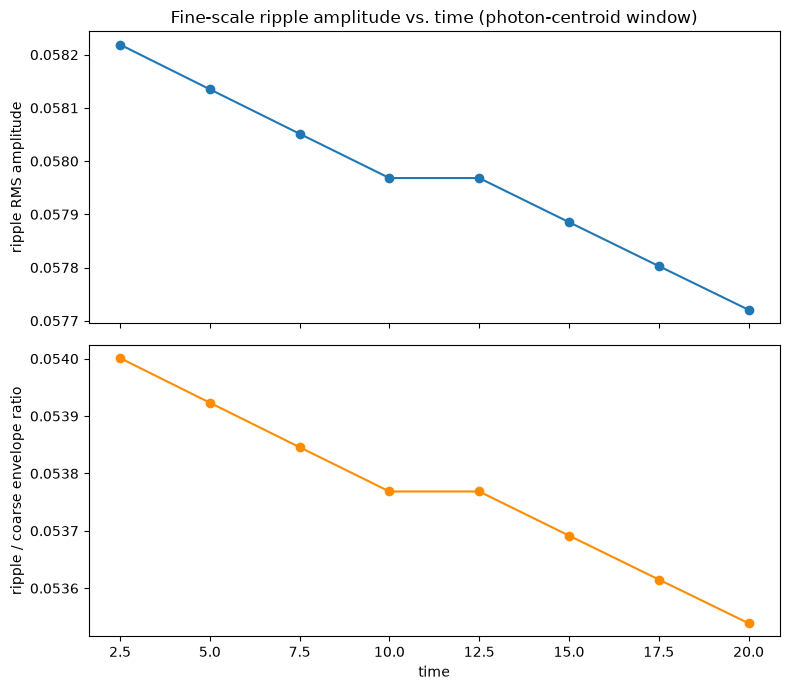

(array([ 2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. ]),
 array([0.05821896, 0.05813501, 0.05805143, 0.0579682 , 0.0579682 ,
        0.05788533, 0.05780281, 0.05772064], dtype=float32),
 array([1.0781058, 1.0781058, 1.0781058, 1.0781058, 1.0781058, 1.0781058,
        1.0781058, 1.0781058], dtype=float32))

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def next_even(n):
    return n if n % 2 == 0 else n + 1

def ripple_amplitude(x1, n, x1lo, x1hi, smooth_window_x1=1.5):
    """Returns the RMS of the high-frequency residual (n - smoothed(n))
    inside [x1lo, x1hi]. smooth_window_x1 should be wider than the
    ripple wavelength but narrower than the overall envelope, so the
    residual isolates fine structure, not the coarse bunching lobes."""
    mask = (x1 >= x1lo) & (x1 <= x1hi)
    x = x1[mask]
    y = n[mask]

    dx = x[1] - x[0]
    window = next_even(int(smooth_window_x1 / dx)) + 1
    window = max(window, 5)
    if window >= len(y):
        window = len(y) - 1 if (len(y) - 1) % 2 == 1 else len(y) - 2
        window = max(window, 5)

    y_smooth = savgol_filter(y, window_length=window, polyorder=3)
    residual = y - y_smooth
    return np.sqrt(np.mean(residual**2)), x, y, y_smooth


def track_ripple_over_dumps(dumps, x2_target=0.0, half_width=15.0,
                             species="plasma", run_dir=".", ms_dir="MS",
                             smooth_window_x1=1.5):
    times, amps, envelope_amps = [], [], []

    for d in dumps:
        try:
            x1, x2, dens_2d = load_density_2d(d, species, run_dir, ms_dir)
        except FileNotFoundError:
            print(f"dump {d}: file not found, skipping")
            continue

        j = np.argmin(np.abs(x2 - x2_target))
        n = dens_2d[j, :]

        lo, hi = find_beam_window_from_photons(d, half_width, run_dir, ms_dir)

        rms, x, y, y_smooth = ripple_amplitude(x1, n, lo, hi, smooth_window_x1)
        coarse_amp = np.max(np.abs(y_smooth - 1.0))

        amps.append(rms)
        envelope_amps.append(coarse_amp)

        try:
            _, _, _, t = load_field_2d(d, "e2", run_dir, ms_dir)
        except Exception:
            t = d
        times.append(t)

        print(f"dump {d}  t={t:.3f}  window=[{lo:.1f},{hi:.1f}]  "
              f"ripple_rms={rms:.5f}  coarse_amp={coarse_amp:.5f}  "
              f"ratio={rms/coarse_amp if coarse_amp>0 else float('nan'):.4f}")

    times, amps, envelope_amps = map(np.array, (times, amps, envelope_amps))

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    axes[0].plot(times, amps, 'o-')
    axes[0].set_ylabel("ripple RMS amplitude")
    axes[0].set_title("Fine-scale ripple amplitude vs. time (photon-centroid window)")
    axes[1].plot(times, amps/envelope_amps, 'o-', color='darkorange')
    axes[1].set_ylabel("ripple / coarse envelope ratio")
    axes[1].set_xlabel("time")
    plt.tight_layout()
    plt.savefig("ripple_growth_check_v2.png", dpi=150)
    plt.show()

    return times, amps, envelope_amps


# find_beam_window from before -- included again here for completeness
def find_beam_window_from_photons(dump, half_width=15.0, run_dir=".", ms_dir="MS"):
    """Locates the beam window using the photon RAW data's charge-weighted
    centroid, which is immune to the vacuum-plasma density ramp."""
    with h5py.File(f"{run_dir}/{ms_dir}/RAW/photons/RAW-photons-{dump:06d}.h5", "r") as f:
        x1 = f["x1"][:]
        q = np.abs(f["q"][:])
    centroid = np.sum(x1 * q) / np.sum(q)
    return centroid - half_width, centroid + half_width


# --- run it ---
track_ripple_over_dumps(dumps=range(1, 9), x2_target=0.0, ms_dir="MS")

## Q3D Analysis

In [37]:
import os
import glob
import re
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

_BEAM_CMAP = LinearSegmentedColormap.from_list("beam", ["black", "darkred", "orange"])


def load_density_2d(dump, species, run_dir=".", window_speed=None, r_shift=None):
    """Load a 2D density field, returning (data_x1x2, x1_coords, x2_coords, time).

    r_shift: radial-axis convention for cylindrical (Q3D) runs.
        0.0  -> p_cell_low  (linear/cubic interpolation): first sample at r=0
        0.5  -> p_cell_near (quadratic/quartic interpolation): first sample at r=dr/2
        None -> Cartesian x2, use plain linspace (unchanged behavior)
    """
    path = f"{run_dir}/MS/DENSITY/{species}/charge/charge-{species}-{dump:06d}.h5"
    with h5py.File(path, "r") as f:
        data = f["charge"][:]              # (nx2, nx1) native storage order
        x1_min, x1_max = f["AXIS"]["AXIS1"][:]
        x2_min, x2_max = f["AXIS"]["AXIS2"][:]
        time = float(f.attrs["TIME"][0])
    data = data.T                           # -> (nx1, nx2)
    n0, n1 = data.shape

    if window_speed is not None:
        shift = window_speed * time
        x1_min -= shift
        x1_max -= shift

    x1_coords = np.linspace(x1_min, x1_max, n0)

    if r_shift is not None:
        dr = (x2_max - x2_min) / n1
        x2_coords = x2_min + (np.arange(n1) + r_shift) * dr
    else:
        x2_coords = np.linspace(x2_min, x2_max, n1)

    return data, x1_coords, x2_coords, time


def _mirror_radial(arr, r_axis):
    """
    Mirrors a (x1, r) array with r>=0 into a full (x1, -r_max..r_max) array
    for display, exploiting azimuthal symmetry. Handles both cases: r_axis
    starting exactly at 0 (odd-order interpolation, p_cell_low) and r_axis
    starting at a half-cell offset (even-order, p_cell_near) -- in the
    former case the r=0 column would otherwise get duplicated, so it's
    dropped from the flipped half.
    """
    if np.isclose(r_axis[0], 0.0, atol=1e-6):
        flipped = arr[:, :0:-1]          # drop the r=0 column before flipping
        flipped_r = -r_axis[:0:-1]
    else:
        flipped = arr[:, ::-1]
        flipped_r = -r_axis[::-1]

    mirrored_arr = np.concatenate([flipped, arr], axis=1)
    mirrored_r = np.concatenate([flipped_r, r_axis])
    return mirrored_arr, mirrored_r


def plot_wake_and_photon_q3d(dump, run_dir=".", plasma_species="plasma", photon_species="photons",
                              window_speed=1.0, plasma_cmap="Blues", plasma_vmax=None,
                              photon_vmax=None, alpha_gamma=1.0, figsize=(11, 5),
                              save_path=None, show=True, r_shift=0.5):

    n_e, x1_e, x2_e, t_e = load_density_2d(dump, plasma_species, run_dir, window_speed, r_shift=r_shift)
    n_ph, x1_ph, x2_ph, t_ph = load_density_2d(dump, photon_species, run_dir, window_speed, r_shift=r_shift)

    n_e = np.abs(n_e)

    n_e_mirror, x2_e_mirror = _mirror_radial(n_e, x2_e)
    n_ph_mirror, x2_ph_mirror = _mirror_radial(n_ph, x2_ph)

    fig, ax = plt.subplots(figsize=figsize)

    vmax_e = plasma_vmax if plasma_vmax is not None else n_e_mirror.max()
    im_e = ax.imshow(n_e_mirror.T, origin="lower", aspect="auto",
                      extent=[x1_e[0], x1_e[-1], x2_e_mirror[0], x2_e_mirror[-1]],
                      cmap=plasma_cmap, vmin=0, vmax=vmax_e)
    cbar_e = fig.colorbar(im_e, ax=ax, pad=0.02, fraction=0.046)
    cbar_e.set_label(f"{plasma_species} density")

    vmax_ph = photon_vmax if photon_vmax is not None else n_ph_mirror.max()
    if vmax_ph > 0:
        norm_ph = np.clip(n_ph_mirror / vmax_ph, 0, 1)
        rgba = _BEAM_CMAP(norm_ph)
        rgba[..., -1] = norm_ph ** alpha_gamma
        rgba_img = np.transpose(rgba, (1, 0, 2))
        ax.imshow(rgba_img, origin="lower", aspect="auto",
                  extent=[x1_ph[0], x1_ph[-1], x2_ph_mirror[0], x2_ph_mirror[-1]])
        sm = plt.cm.ScalarMappable(cmap=_BEAM_CMAP, norm=plt.Normalize(0, vmax_ph))
        cbar_ph = fig.colorbar(sm, ax=ax, pad=0.08, fraction=0.046)
        cbar_ph.set_label(f"{photon_species} density")

    xlabel = r"$\xi = x_1 - v_{win}t$" if window_speed is not None else r"$x_1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$r$ (mirrored)")
    ax.set_xlim(50, 100)
    ax.set_ylim(-10, 10)
    ax.set_title(f"dump={dump}, t={t_e:.1f}  [Q3D]")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return n_e, n_ph

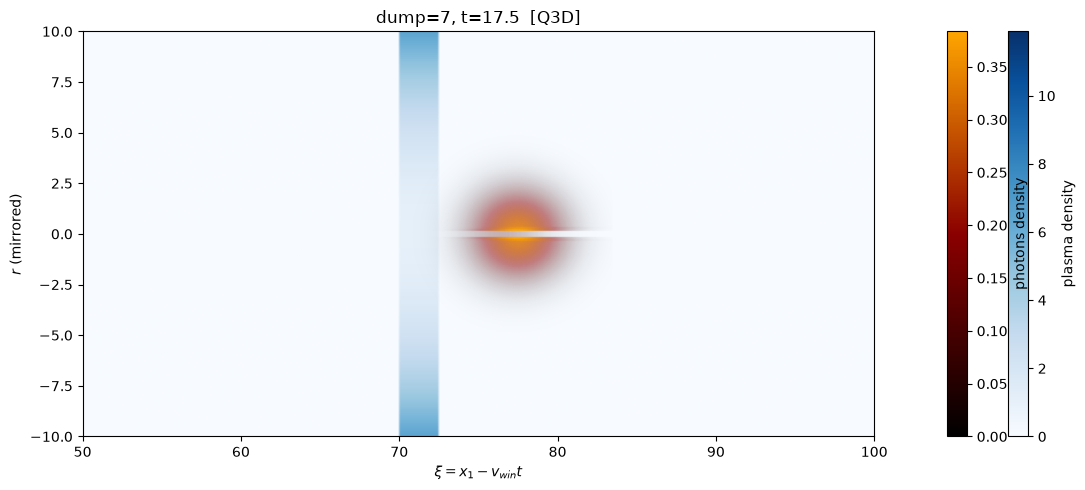

In [49]:
plot_wake_and_photon_q3d(
    dump=7,                      # matches the n(tstep)==8*ndump debug dump in your Fortran
    run_dir=".",
    plasma_species="plasma",
    photon_species="photons",
    window_speed=0.0,
    r_shift=0.5,
);

In [39]:
data, x1, x2, t = load_density_2d(dump=6, species="photons", run_dir=".",
                                   window_speed=0.0, r_shift=0.5)

# find the x1 column near the lens (same region as your plot, e.g. xi ~ 75)
i1 = np.argmin(np.abs(x1 - 75))

print("r values near axis:", x2[:5])
print("density near axis :", data[i1, :5])

r values near axis: [0.  0.1 0.2 0.3 0.4]
density near axis : [0.11412374 0.11412374 0.38247    0.34566706 0.32070118]


In [33]:
def _raw_path(dump, run_dir="."):
    return f"{run_dir}/MS/RAW/photons/RAW-photons-{dump:06d}.h5"
 
 
def _tag_columns(tag):
    """
    Return (node, local_id) as two 1D arrays regardless of whether `tag` is
    stored as (2, N) -- one row per field -- or (N, 2) -- one row per
    particle. Handles both since OSIRIS builds/versions differ on this.
    """
    tag = np.asarray(tag)
    if tag.ndim != 2:
        raise ValueError(f"expected a 2D tag array, got shape {tag.shape}")
    if tag.shape[0] == 2 and tag.shape[1] != 2:
        return tag[0], tag[1]
    elif tag.shape[1] == 2 and tag.shape[0] != 2:
        return tag[:, 0], tag[:, 1]
    else:
        # ambiguous (exactly 2 particles) -- assume (2, N) OSIRIS convention
        return tag[0], tag[1]
 
 
def list_tags_in_dump(dump, run_dir=".", n=10, near_x2=None, x1_window=None):
    """
    Return a handful of (node, id) tags present in a given dump, for you to
    pick from. Optionally filter to particles near a given x2 (e.g. near_x2=0
    for an on-axis check) and/or within an x1_window (e.g. near the photon
    source at early times).
    """
    with h5py.File(_raw_path(dump, run_dir), "r") as f:
        tag = f["tag"][:]
        x1 = f["x1"][:]
        x2 = f["x2"][:]
 
    node, lid = _tag_columns(tag)
 
    mask = np.ones(x1.shape, dtype=bool)
    if near_x2 is not None:
        mask &= np.abs(x2 - near_x2) < 0.25
    if x1_window is not None:
        mask &= (x1 >= x1_window[0]) & (x1 <= x1_window[1])
 
    idx = np.where(mask)[0][:n]
    return [(node[i], lid[i]) for i in idx]
 
 
def build_trajectory(target_tag, dumps, run_dir="."):
    """
    Follow a single tagged photon across a sequence of dump indices.
    Returns a dict of arrays: t, x1, x2, p1, p2, p3 (only for dumps where
    the tag was found -- particles can leave the box).
    """
    out = {k: [] for k in ("t", "x1", "x2", "p1", "p2", "p3")}
 
    for dump in dumps:
        path = _raw_path(dump, run_dir)
        try:
            with h5py.File(path, "r") as f:
                tag = f["tag"][:]
                node, lid = _tag_columns(tag)
                match = np.where((node == target_tag[0]) & (lid == target_tag[1]))[0]
                if match.size == 0:
                    continue
                i = match[0]
                out["t"].append(float(f.attrs["TIME"][0]))
                out["x1"].append(f["x1"][i])
                out["x2"].append(f["x2"][i])
                out["p1"].append(f["p1"][i])
                out["p2"].append(f["p2"][i])
                out["p3"].append(f["p3"][i])
        except FileNotFoundError:
            continue
 
    return {k: np.array(v) for k, v in out.items()}
 
 
def _channel_rhs(z, y, Omega, in_channel):
    """
    Ray-optics ODE in terms of x2(z), dx2/dz where z = x1 - z_lens0.
    Paraxial harmonic restoring force inside the channel, free streaming
    (straight line) outside it. y = [x2, x2']
    """
    x2, x2p = y
    if in_channel(z):
        return [x2p, -Omega**2 * x2]
    else:
        return [x2p, 0.0]
 
 
def predict_from_entrance(x2_entrance, slope_entrance, x1_grid,
                           w_ch, beta, k0, z_lens0, z_lens1):
    """
    Integrate the SAME linear-optics model your analytic curve uses, but
    seeded with one particle's own (x2, dx2/dx1) at the moment it crosses
    z_lens0 -- rather than assuming the nominal x2_0=1.5, slope=0 used for
    the ensemble RMS curve. This is the correct single-particle comparison.
    """
    omega0 = np.sqrt(1 + k0**2)
    Omega = np.sqrt(beta / (omega0**2 * w_ch**2))
 
    def in_channel(z):
        return 0.0 <= z <= (z_lens1 - z_lens0)
 
    z_grid = x1_grid - z_lens0
    sol = solve_ivp(_channel_rhs, (z_grid.min(), z_grid.max()),
                     [x2_entrance, slope_entrance],
                     t_eval=z_grid, args=(Omega, in_channel),
                     max_step=0.05, rtol=1e-9, atol=1e-12)
    return sol.y[0]
 
 
def plot_trajectory_vs_ode(traj, w_ch, beta, k0, z_lens0, z_lens1,
                            entrance_x1=None):
    """
    Overlay one particle's actual x2(x1) against the per-particle ODE
    prediction, seeded from the particle's own state at/just before
    z_lens0. If entrance_x1 isn't given, uses the trajectory point closest
    to z_lens0 as the entrance condition.
    """
    x1, x2, p1, p2 = traj["x1"], traj["x2"], traj["p1"], traj["p2"]
    order = np.argsort(x1)
    x1, x2, p1, p2 = x1[order], x2[order], p1[order], p2[order]
 
    if entrance_x1 is None:
        i0 = np.argmin(np.abs(x1 - z_lens0))
    else:
        i0 = np.argmin(np.abs(x1 - entrance_x1))
 
    x2_entrance = x2[i0]
    slope_entrance = p2[i0] / p1[i0]   # dx2/dx1 at entrance, from momenta
 
    x2_pred = predict_from_entrance(x2_entrance, slope_entrance, x1,
                                     w_ch, beta, k0, z_lens0, z_lens1)
 
    plt.figure(figsize=(8, 4.5))
    plt.plot(x1, x2, '.', ms=3, label="sim (single tagged photon)")
    plt.plot(x1, x2_pred, 'k--', label="per-particle ODE prediction")
    plt.axvline(z_lens0, color='gray', ls=':', label='lens entrance')
    plt.axvline(z_lens1, color='orange', ls=':', label='lens exit')
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
 
    return x1, x2, x2_pred


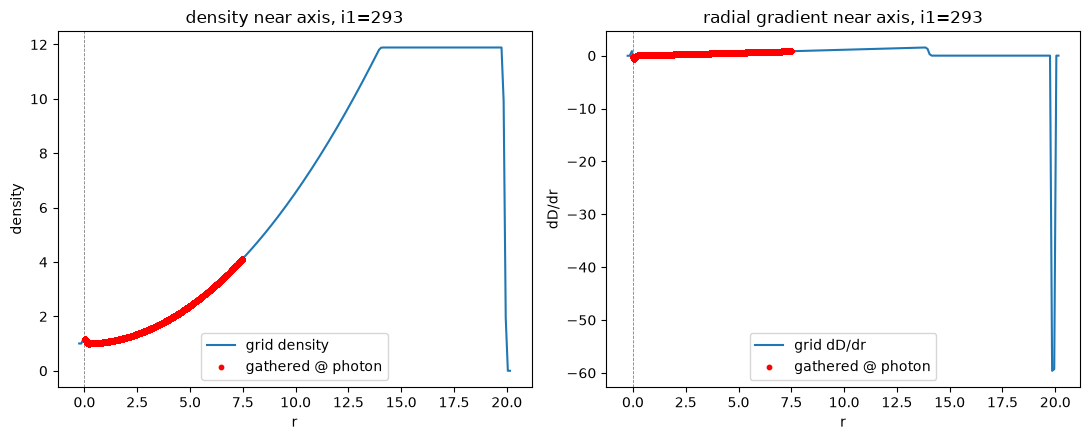

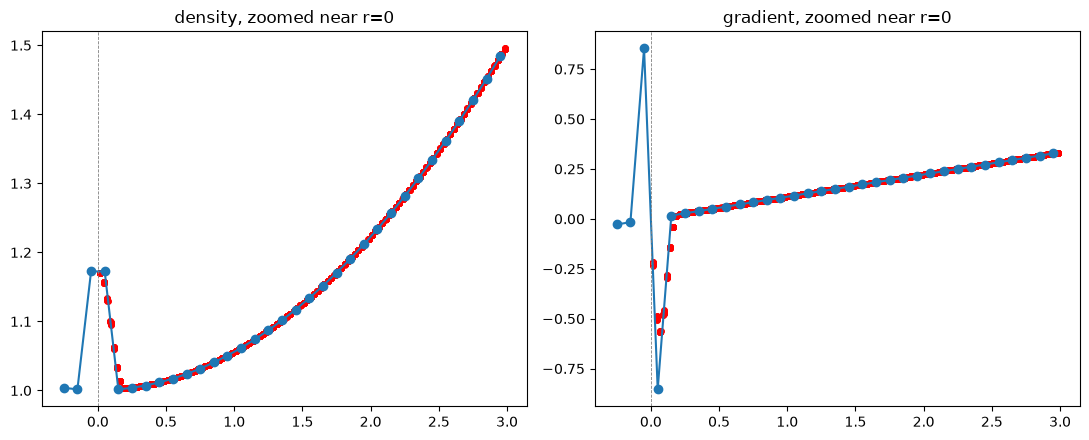

In [29]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.loadtxt('grid_profile_debug.dat')
part = np.loadtxt('particle_profile_debug.dat')

# grid columns: i1, i2, r, density, grad_r
# part columns: ip, ix1, r_phys, density_at_p, gradr_at_p

# ---- pick the i1 (axial) slice near the lens where the notch shows up ----
i1_target = 293     # <-- set this to match whatever showed the notch in your plot
i1_window = 2        # tolerance in cells for selecting nearby photons

grid_slice = grid[grid[:, 0] == i1_target]
grid_slice = grid_slice[np.argsort(grid_slice[:, 2])]   # sort by r for clean lines

part_slice = part[np.abs(part[:, 1] - i1_target) <= i1_window]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# --- density panel ---
ax[0].plot(grid_slice[:, 2], grid_slice[:, 3], '-', color='C0', label='grid density')
ax[0].scatter(part_slice[:, 2], part_slice[:, 3], s=10, color='r',
              label='gathered @ photon', zorder=5)
ax[0].axvline(0, color='gray', lw=0.6, ls='--')
ax[0].set_xlabel('r')
ax[0].set_ylabel('density')
ax[0].set_title(f'density near axis, i1={i1_target}')
ax[0].legend()

# --- gradient panel ---
ax[1].plot(grid_slice[:, 2], grid_slice[:, 4], '-', color='C0', label='grid dD/dr')
ax[1].scatter(part_slice[:, 2], part_slice[:, 4], s=10, color='r',
              label='gathered @ photon', zorder=5)
ax[1].axvline(0, color='gray', lw=0.6, ls='--')
ax[1].set_xlabel('r')
ax[1].set_ylabel('dD/dr')
ax[1].set_title(f'radial gradient near axis, i1={i1_target}')
ax[1].legend()

plt.tight_layout()
plt.savefig('axis_profile_check.png', dpi=150)
plt.show()

# ---- zoom in tight around r=0 to inspect the interface cell directly ----
r_zoom = 3.0
mask_g = np.abs(grid_slice[:, 2]) < r_zoom
mask_p = np.abs(part_slice[:, 2]) < r_zoom

fig2, ax2 = plt.subplots(1, 2, figsize=(11, 4.5))
ax2[0].plot(grid_slice[mask_g, 2], grid_slice[mask_g, 3], 'o-', color='C0')
ax2[0].scatter(part_slice[mask_p, 2], part_slice[mask_p, 3], s=14, color='r')
ax2[0].axvline(0, color='gray', lw=0.6, ls='--')
ax2[0].set_title('density, zoomed near r=0')

ax2[1].plot(grid_slice[mask_g, 2], grid_slice[mask_g, 4], 'o-', color='C0')
ax2[1].scatter(part_slice[mask_p, 2], part_slice[mask_p, 4], s=14, color='r')
ax2[1].axvline(0, color='gray', lw=0.6, ls='--')
ax2[1].set_title('gradient, zoomed near r=0')

plt.tight_layout()
plt.savefig('axis_profile_zoom.png', dpi=150)
plt.show()